>
---
Packages imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# Load Data
df = pd.read_csv('../data/kidney_disease.csv')
df = df.drop('id', axis=1)

print(df['classification'].value_counts())

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


>
---
Encoding & Transformation

In [22]:
# Clean Strings (Remove tabs/spaces)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# BINARY MAP (Convert words to numbers BEFORE the safety net)
binary_map = {
    'yes': 1, 'no': 0, 
    'normal': 1, 'abnormal': 0, 
    'present': 1, 'notpresent': 0, 
    'good': 1, 'poor': 0,
    'ckd': 1, 'notckd': 0
}

# Apply mapping to the whole dataframe
# Columns that don't match these words (like numbers) will stay the same
df = df.replace(binary_map)

# SAFETY NET: Convert any remaining non-numeric values to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill those NaNs with the median of each column
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

# Even though we mapped 'ckd' to 1, we use LE on the target to be 100% safe for the model
le = LabelEncoder()
df['classification'] = le.fit_transform(df['classification'])

print(f"New shape of data: {df.shape}")
print(df.head())


New shape of data: (400, 25)
    age    bp     sg   al   su  rbc   pc  pcc   ba    bgr  ...   pcv      wc  \
0  48.0  80.0  1.020  1.0  0.0  1.0  1.0  0.0  0.0  121.0  ...  44.0  7800.0   
1   7.0  50.0  1.020  4.0  0.0  1.0  1.0  0.0  0.0  121.0  ...  38.0  6000.0   
2  62.0  80.0  1.010  2.0  3.0  1.0  1.0  0.0  0.0  423.0  ...  31.0  7500.0   
3  48.0  70.0  1.005  4.0  0.0  1.0  0.0  1.0  0.0  117.0  ...  32.0  6700.0   
4  51.0  80.0  1.010  2.0  0.0  1.0  1.0  0.0  0.0  106.0  ...  35.0  7300.0   

    rc  htn   dm  cad  appet   pe  ane  classification  
0  5.2  1.0  1.0  0.0    1.0  0.0  0.0               1  
1  4.8  0.0  0.0  0.0    1.0  0.0  0.0               1  
2  4.8  0.0  1.0  0.0    0.0  0.0  1.0               1  
3  3.9  1.0  0.0  0.0    0.0  1.0  1.0               1  
4  4.6  0.0  0.0  0.0    1.0  0.0  0.0               1  

[5 rows x 25 columns]


C:\Users\user\AppData\Local\Temp\ipykernel_79548\1385578569.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


>
---
Exploratory Data Analysis (Visualization)

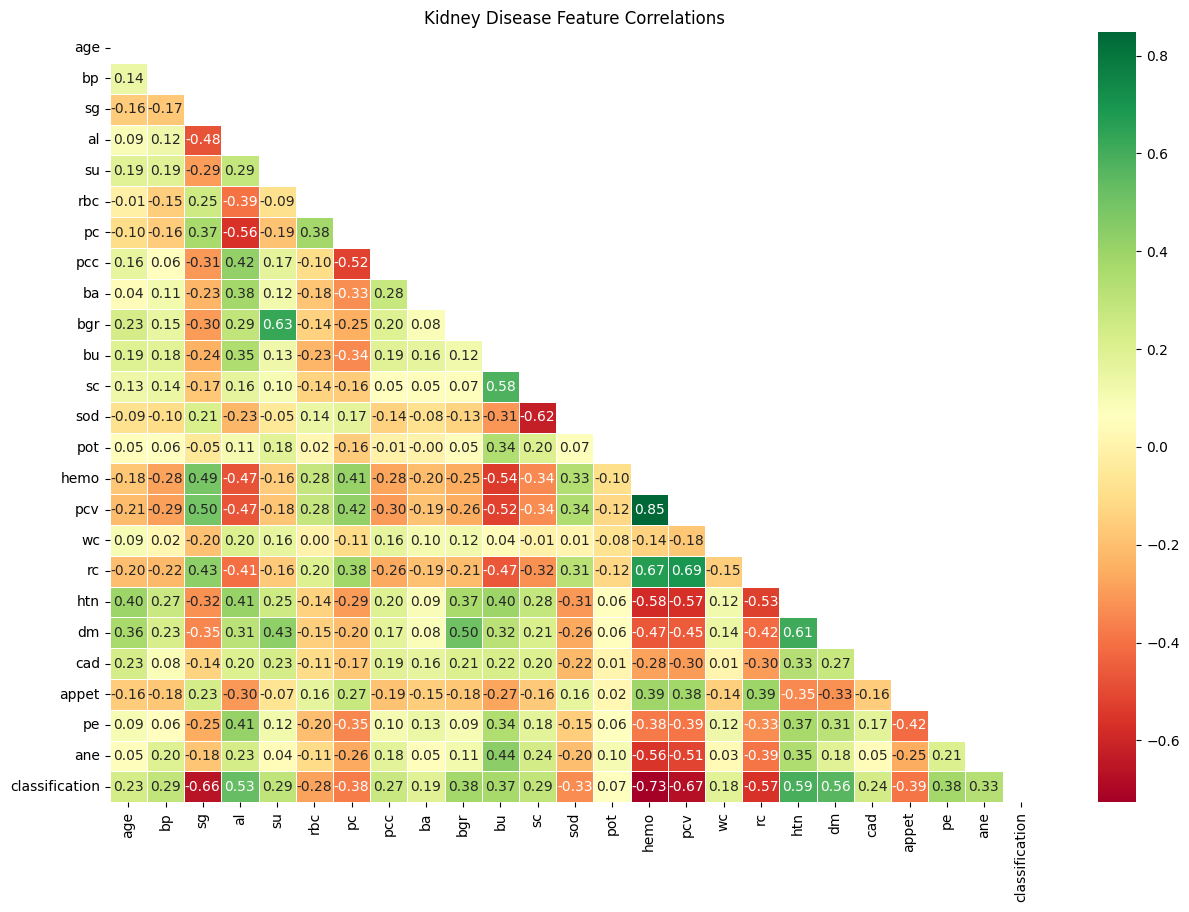

In [23]:
# 3. The Heatmap
plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt='.2f', mask=mask, cmap='RdYlGn', linewidths=0.5)
plt.title('Kidney Disease Feature Correlations')
plt.show()

>
---
Data splitting & scaling

In [24]:
# Split Data
X = df.drop('classification', axis=1)
y = df['classification']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

>
---
Traning & Evaluation


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



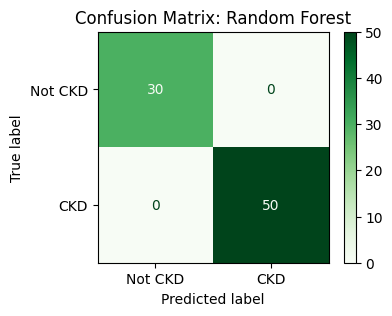


--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



c:\Users\user\OneDrive\Desktop\Medical_AI_Suite\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:42:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


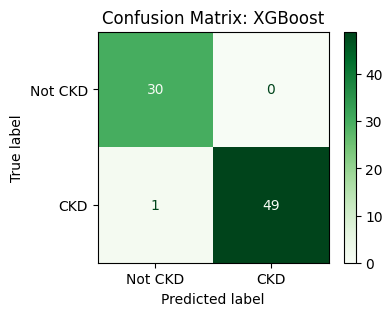


--- SVM Performance ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



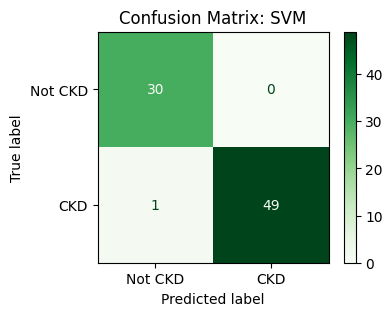

In [25]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# Train and Evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n--- {name} Performance ---")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Not CKD', 'CKD'], cmap='Greens', ax=ax)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

>
---
Feature Importance

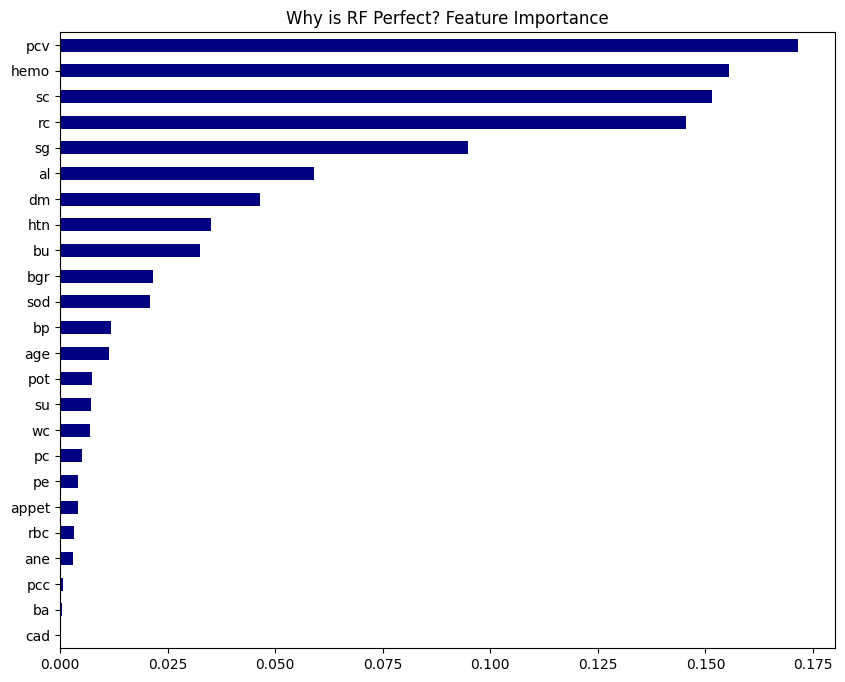

In [26]:
# Feature Importance for RF model
importances = models['Random Forest'].feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importances.plot(kind='barh', color='navy')
plt.title('Why is RF Perfect? Feature Importance')
plt.show()

>
---
Saving the model

In [27]:
joblib.dump(models['Random Forest'], '../models/kidney_model.pkl')

# 2. Save the scaler 
joblib.dump(scaler, '../models/kidney_scaler.pkl')

print("Kidney Model and Scaler saved successfully!")

Kidney Model and Scaler saved successfully!
